# Comparison of SVM and Deep Learning Models

Community is the best performing spatial unit for the Neural Network and the SVM. For the NN it is the hourly level and for the SVM it is the daily level though. We will compare the models for both temporal levels against each other and the base line on the test set.

Rather than re-loading and re-running the models, this notebook loads only their already-computed predictions on the held-out
test split plus the historical-mean baseline.

All three signals (baseline, SVM, NN) live as columns of a single testing_df, so each cell is just a different slice/aggregation of that one frame.

In [47]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import shapely
import mapclassify
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INDEX = "commarea"
TRUTH = "y_true"
BASELINE_COL = "base_demand"

SVR_DIR = Path("../models_predictions/SVR/residual/predictions")
FNN_DIR = Path("../models_predictions/FNN/standard/community")

predictions = {
    "svm": {"col": "y_pred_svr", "name": "Best SVM (Residual SVR)"},
    "nn": {"col": "y_pred_fnn", "name": "Neural Network (FNN)"},
}

def score(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def load_comparison(temporal):
    svr = pd.read_parquet(SVR_DIR / f"test_pred_community_{temporal}.parquet")
    fnn = pd.read_parquet(FNN_DIR / f"FNN_community_{temporal}.parquet")
    svr.rename(columns={"Total_Trip_Start": "y_true", "SVR_pred": "y_pred"}, inplace=True)
    # Merge on spatial unit + time only
    # Keep a single y_true column, taken from the SVR file, and drop the FNN copy before merging.
    fnn = fnn.drop(columns="y_true")
    merged = svr.merge(fnn, on=[INDEX, "timestamp"], suffixes=("_svr", "_fnn"))
    return merged

comparisons = {
    "daily": load_comparison("daily"),
    "hourly": load_comparison("hourly"),
}

print("Loaded:")
for temporal, df in comparisons.items():
    print(f"Community/{temporal}: {len(df)} rows")

Loaded:
Community/daily: 19943 rows
Community/hourly: 478632 rows


## Performance Metrics Table

Historical-mean baseline (`base_demand`) plus the best SVM and the neural network, scored on the
full `Community/daily` held-out **test** set.

In [48]:
#| label: tbl-svm-vs-nn-overall
#| tbl-cap: "Overall TEST performance at community level."
#| tbl-subcap:
#|   - "community/daily"
#|   - "community/hourly"
for temporal, testing_df in comparisons.items():
    rows = [score(testing_df[TRUTH].values, testing_df[BASELINE_COL].values, "Baseline")]
    for p in predictions.values():
        rows.append(score(testing_df[TRUTH].values, testing_df[p["col"]].values, p["name"]))
    display(pd.DataFrame(rows).set_index("Model").round(4))

,MAE,RMSE,R2
Model,,,
Baseline,49.5750,181.9158,0.9283
Best SVM (Residual SVR),46.3370,164.6925,0.9413
Neural Network (FNN),54.5184,190.6171,0.9213


,MAE,RMSE,R2
Model,,,
Baseline,2.9029,11.0871,0.9019
Best SVM (Residual SVR),2.8777,11.2611,0.8988
Neural Network (FNN),2.6201,9.6776,0.9252


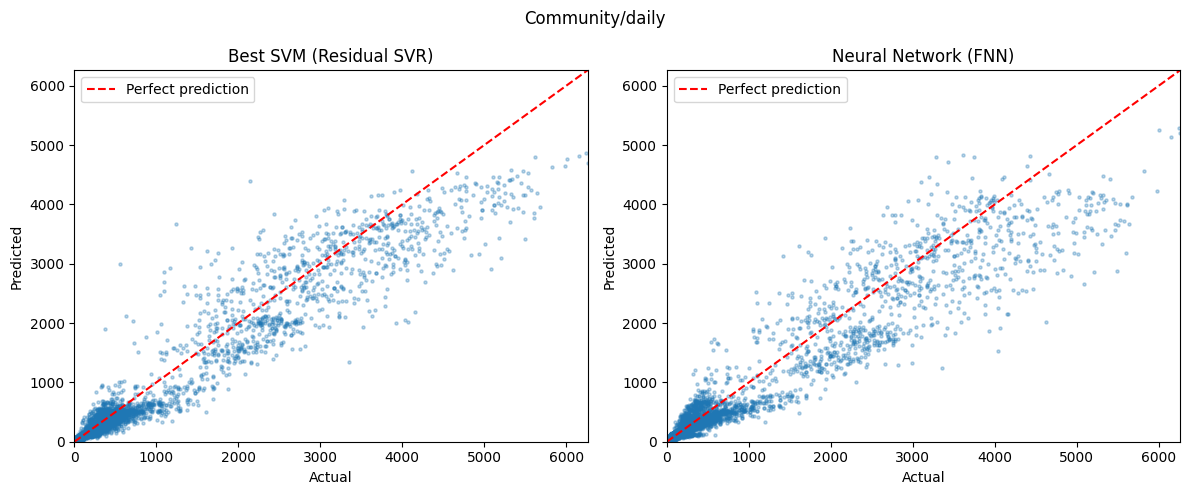

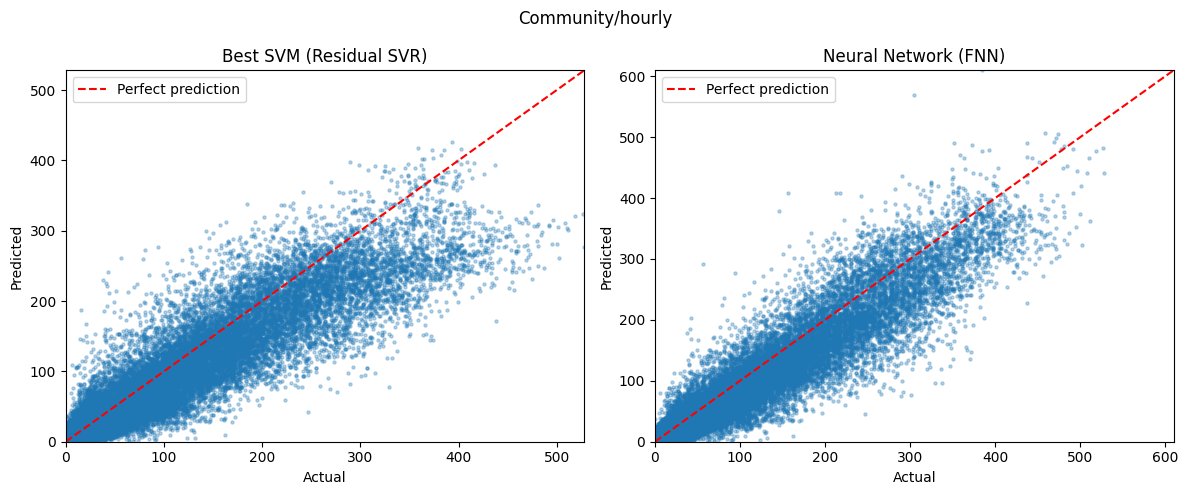

In [49]:
#| label: fig-svm-vs-nn-scatter
#| fig-cap: "Actual vs. predicted demand per temporal resolution."
#| fig-subcap:
#|   - " "
#|   - " "
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    y_true = testing_df[TRUTH].values
    fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5), squeeze=False)
    fig.suptitle(f"Community/{temporal}")
    for ax, (key, p) in zip(axes[0], predictions.items()):
        pred = testing_df[p["col"]].values
        lim = max(y_true.max(), pred.max())
        ax.scatter(y_true, pred, alpha=0.3, s=5)
        ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(p["name"])
        ax.legend()
    plt.tight_layout()
    plt.show()

## Spatial Prediction Quality

The aggregate metrics above collapse the whole city into a single number and hide strong
**spatial** variation in how well each model performs. Here we aggregate error by community
area and compare SVM and FNN side by side.

- **MAE per community area**: The absolute size of the prediction miss (trips/day).
- **Relative error per community area**: The miss size relative to that area's own mean demand.
- **R² per community area**: How much of each area's day-to-day demand variation the model
  explains. (Areas whose demand is essentially flat have no variation to explain, so their
  R² is undefined and they are greyed out.)

In [50]:
# Community area outlines, used as a spatial reference overlay in the choropleths.
tracts = gpd.read_file(Path("..") / "data" / "chicago_census_comm.gpkg")
community_areas = tracts.dissolve(by="commarea")

def get_community_performance_metrics(df_eval, pred_col, target_col=TRUTH):
    d = df_eval[[INDEX, target_col, pred_col]].copy()
    d["abs_err"] = (d[target_col] - d[pred_col]).abs()
    d["sq_err"] = (d[target_col] - d[pred_col]) ** 2
    grp = d.groupby(INDEX)
    perf = pd.DataFrame({
        "mae": grp["abs_err"].mean(),
        "rel_error": grp["abs_err"].mean() / grp[target_col].mean().replace(0, np.nan),
        "r2": grp.apply(lambda x: r2_score(x[target_col], x[pred_col]) if len(x) > 1 else np.nan),
        "mean_actual": grp[target_col].mean(),
    })
    return community_areas.join(perf, how="left")

def shared_quantile_bins(gdfs, value_col, k=7):
    """Quantile bin edges pooled over every gdf's `value_col`, so all subplots in a figure share
    one classification (identical colors + legend) and are directly comparable."""
    pooled = pd.concat([gdf[value_col] for gdf in gdfs]).replace([np.inf, -np.inf], np.nan).dropna()
    return mapclassify.Quantiles(pooled, k=k).bins


def create_choropleth_plot(ax, gdf, value_col, title="", cmap="YlOrRd", k=7, bins=None):
    """Plot one quantile choropleth of a area-level metric onto ax, with a Chicago basemap and
    community-area boundary overlay. Pass `bins` (from `shared_quantile_bins`) to force a fixed
    classification shared across subplots so their legends line up for comparison."""
    if bins is not None:
        scheme_kwds = dict(scheme="UserDefined", classification_kwds={"bins": list(bins)})
    else:
        scheme_kwds = dict(scheme="quantiles", k=k)
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
        **scheme_kwds,
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

### Map 1: mean absolute error (MAE) per area

Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop;
the quiet outskirts have tiny MAE simply because there is little demand.


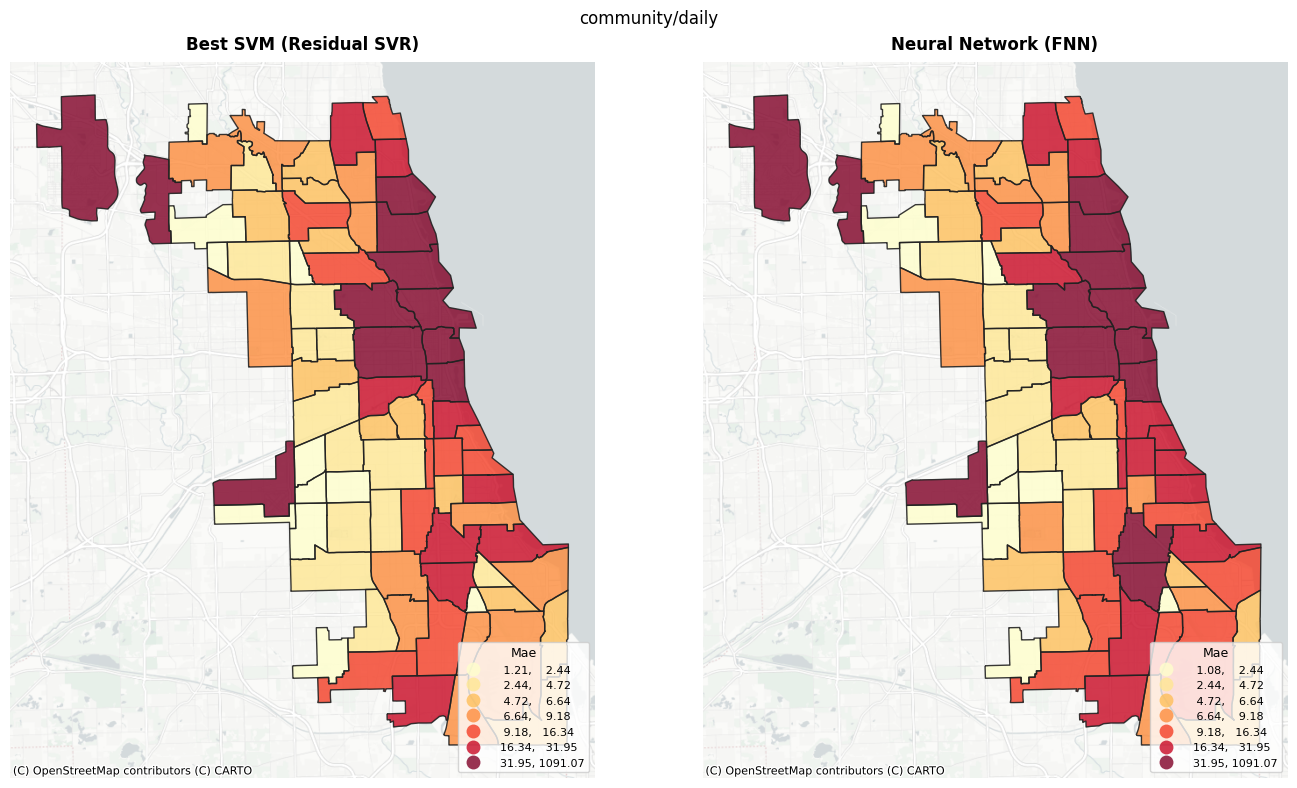

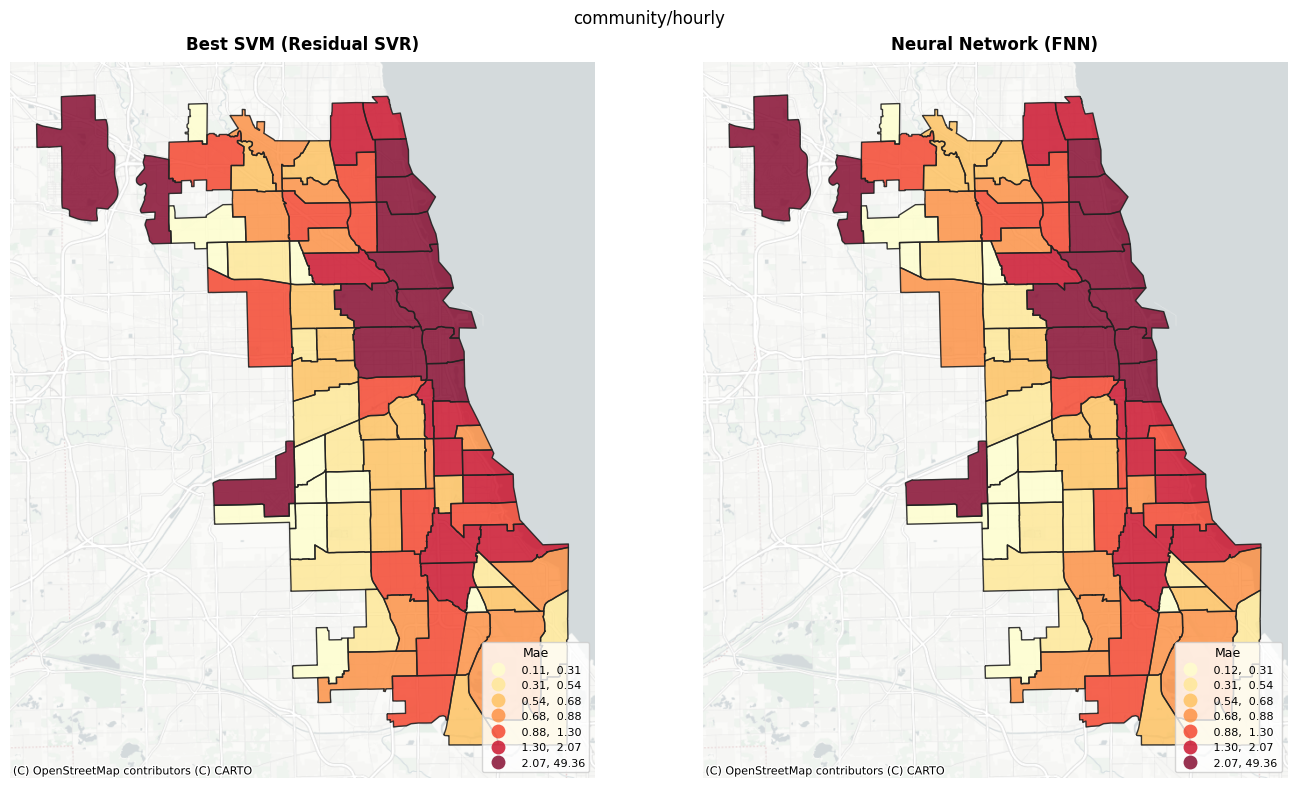

In [51]:
#| label: fig-svm-hex-mae
#| fig-cap: "MAE per community area per temporal resolution."
#| fig-subcap:
#|   - " "
#|   - " "
for temporal, testing_df in comparisons.items():
    area_data = {key: get_community_performance_metrics(testing_df, pred_col=p["col"])
                for key, p in predictions.items()}
    bins = shared_quantile_bins(list(area_data.values()), "mae")
    fig, axes = plt.subplots(1, len(area_data), figsize=(7 * len(area_data), 8), squeeze=False)
    fig.suptitle(f"community/{temporal}")
    for ax, (key, gdf) in zip(axes[0], area_data.items()):
        create_choropleth_plot(ax, gdf, "mae", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()


### Map 2: mean relative error (MRE) per area

The miss size relative to each cell's own mean demand -- this is what makes small-demand
outskirts visible instead of always looking "perfect" on raw MAE alone.


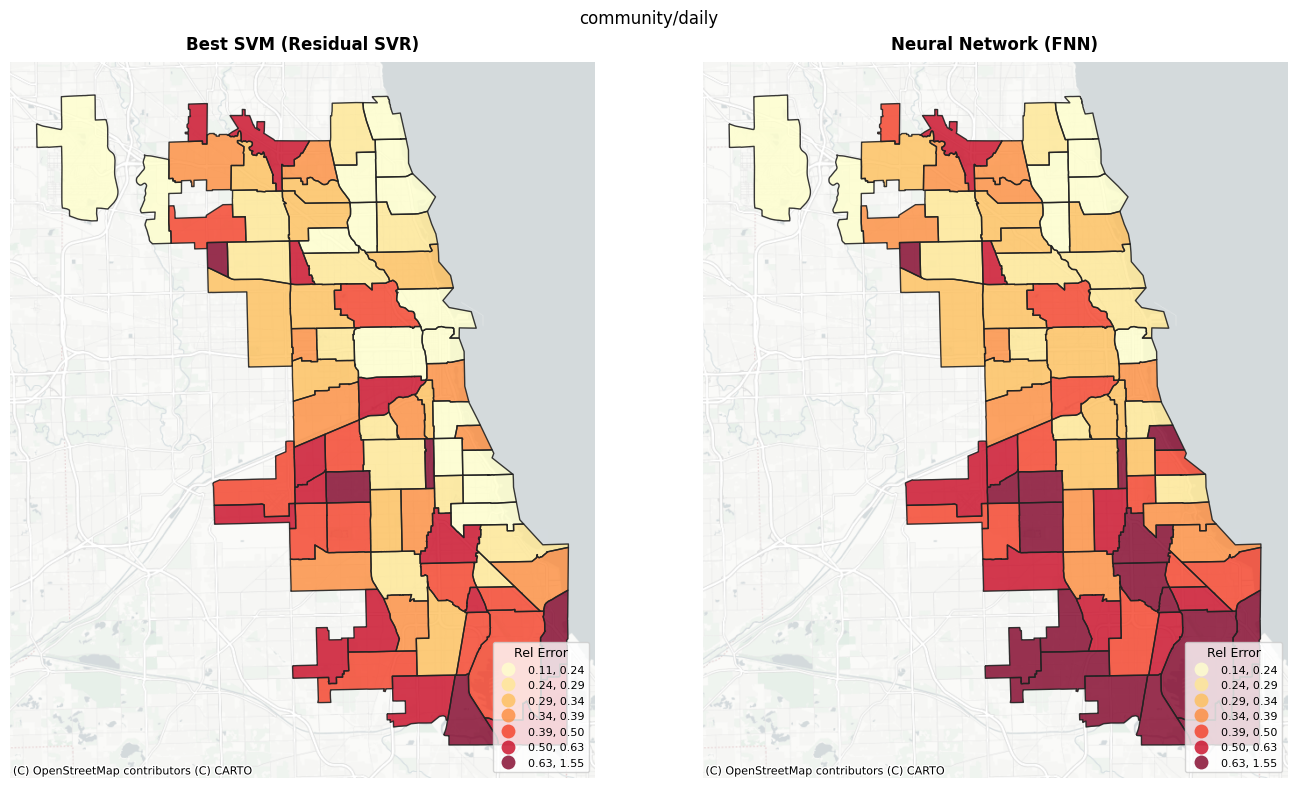

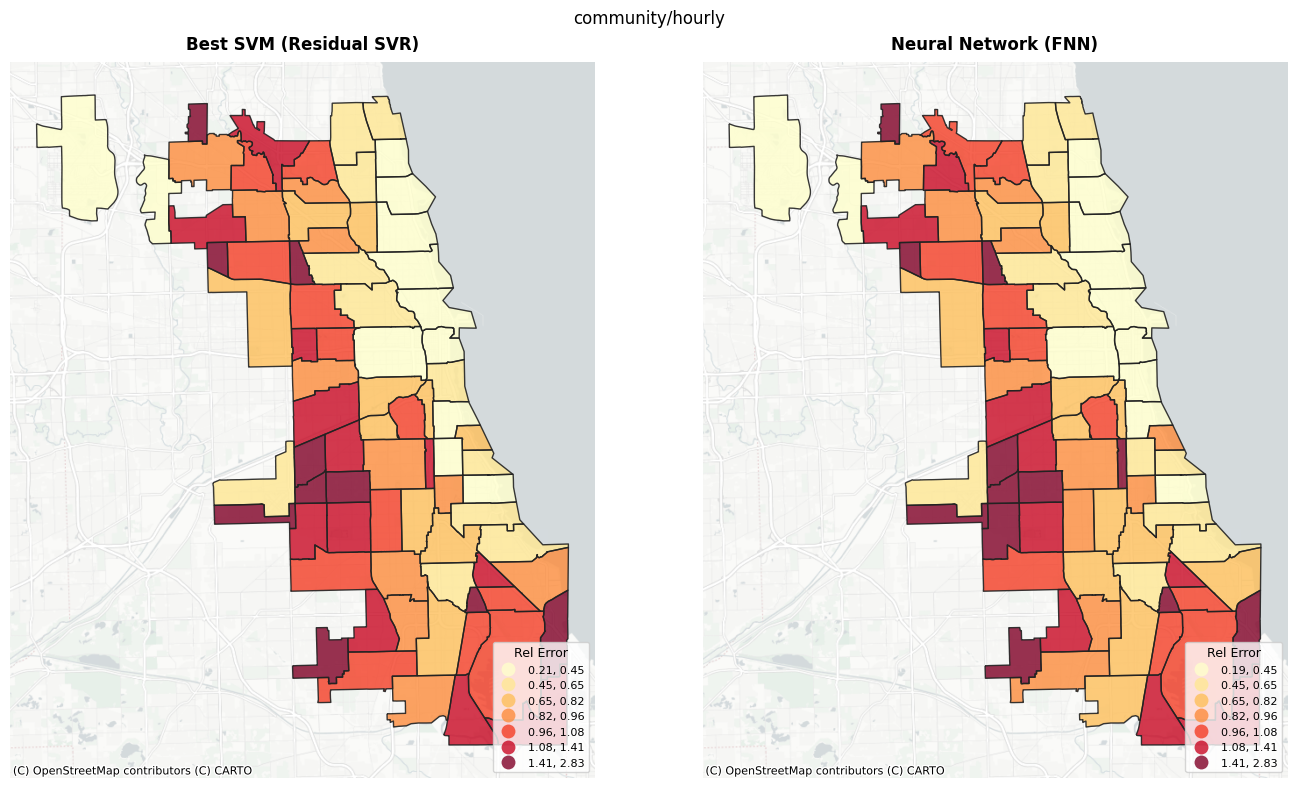

In [52]:
#| label: fig-svm-hex-mre
#| fig-cap: "Relative error per community area per temporal resolution."
#| fig-subcap:
#|   - " "
#|   - " "
for temporal, testing_df in comparisons.items():
    area_data = {key: get_community_performance_metrics(testing_df, pred_col=p["col"])
                for key, p in predictions.items()}
    bins = shared_quantile_bins(list(area_data.values()), "rel_error")
    fig, axes = plt.subplots(1, len(area_data), figsize=(7 * len(area_data), 8), squeeze=False)
    fig.suptitle(f"community/{temporal}")
    for ax, (key, gdf) in zip(axes[0], area_data.items()):
        create_choropleth_plot(ax, gdf, "rel_error", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()

### Map 3: coefficient of determination (R2) per area

Green = the day-to-day demand pattern is captured well; red = poorly; grey = too little demand
variation to assess.


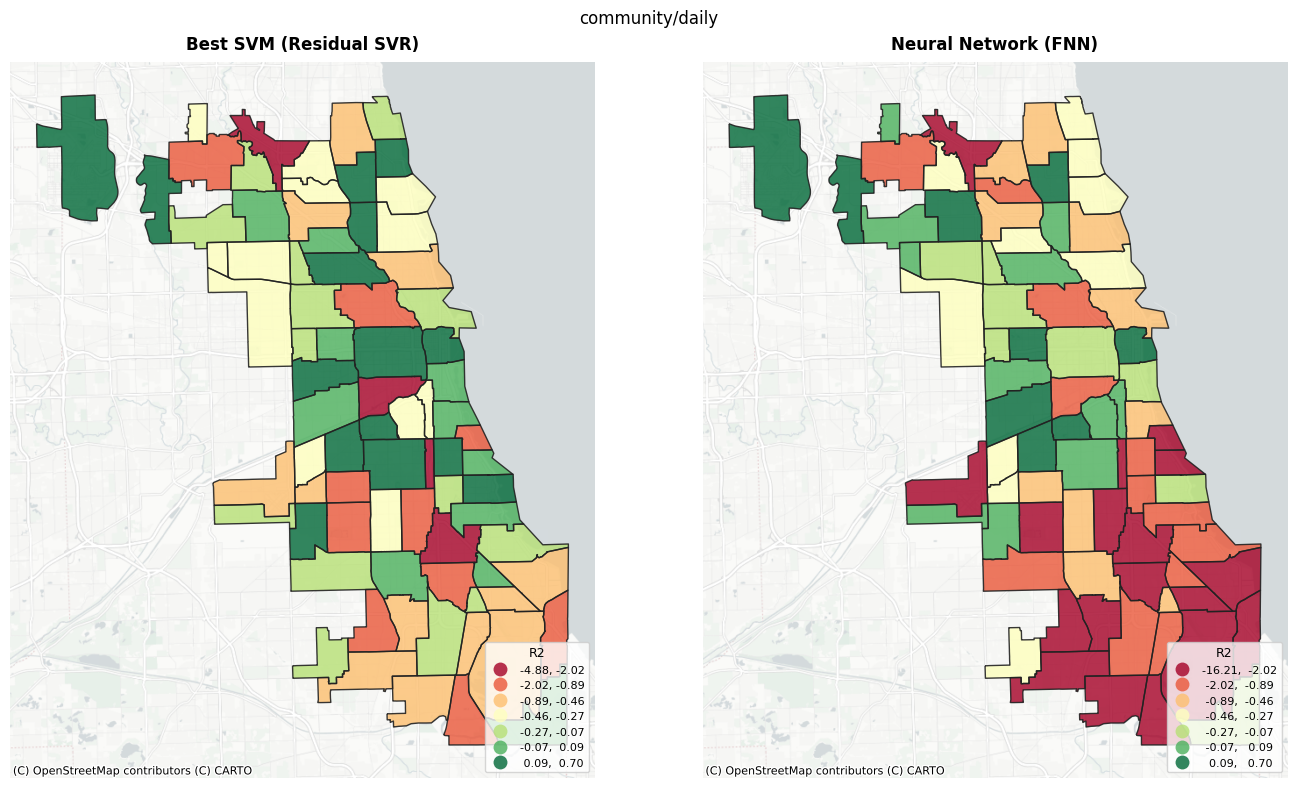

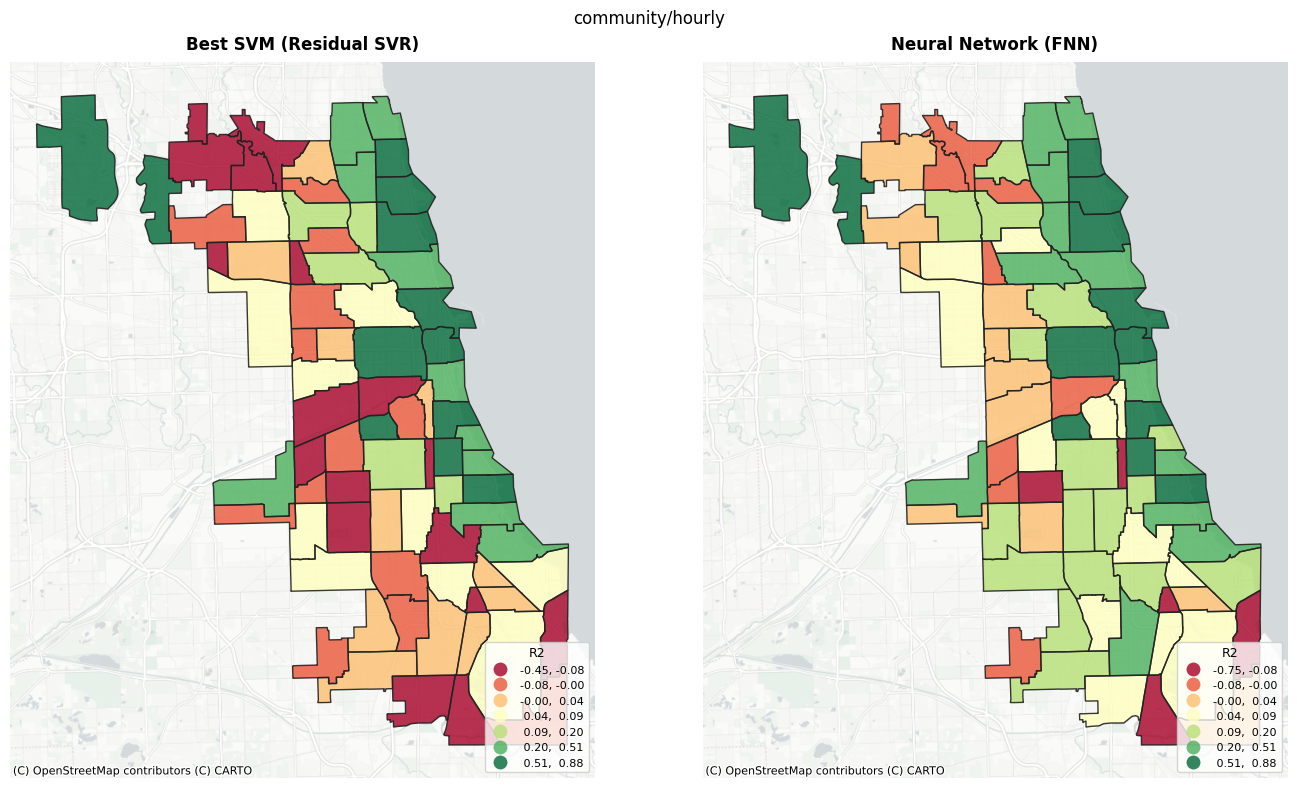

In [53]:
#| label: fig-svm-hex-r2
#| fig-cap: "R² per community area per temporal resolution."
#| fig-subcap:
#|   - " "
#|   - " "
for temporal, testing_df in comparisons.items():
    area_data = {key: get_community_performance_metrics(testing_df, pred_col=p["col"])
                for key, p in predictions.items()}
    bins = shared_quantile_bins(list(area_data.values()), "r2")
    fig, axes = plt.subplots(1, len(area_data), figsize=(7 * len(area_data), 8), squeeze=False)
    fig.suptitle(f"community/{temporal}")
    for ax, (key, gdf) in zip(axes[0], area_data.items()):
        create_choropleth_plot(ax, gdf, "r2", title=predictions[key]["name"], cmap="RdYlGn", bins=bins)
    plt.tight_layout()
    plt.show()


### Map 4: where does one model beat the other?

The three maps above put the SVM and the NN side by side, but reading "who wins where" off two separate color scales is hard. This map plots the difference directly:

`MAE_NN - MAE_SVM` per area. 
**Blue means the SVM has the lower error there (SVM wins); Red means the NN does.**

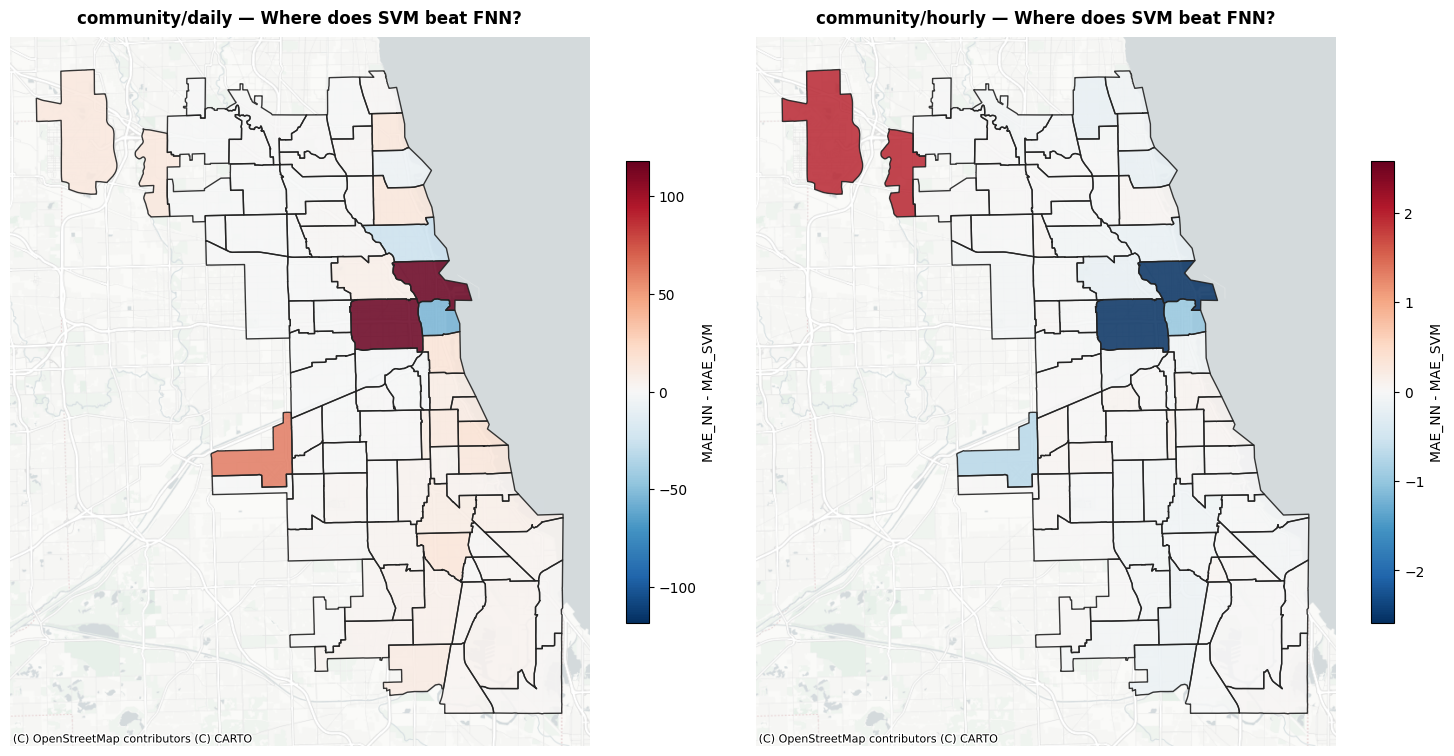

In [54]:
#| label: fig-svm-vs-nn-hex-delta
#| fig-cap: "MAE_NN - MAE_SVM per community area per temporal resolution. Blue = FNN wins, red = SVM wins."

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, (temporal, testing_df) in zip(axes, comparisons.items()):
    area_data = {key: get_community_performance_metrics(testing_df, pred_col=p["col"])
                for key, p in predictions.items()}
    delta = area_data["svm"][["mae"]].join(area_data["nn"][["mae"]], lsuffix="_svm", rsuffix="_nn")
    delta["mae_delta"] = delta["mae_nn"] - delta["mae_svm"]
    delta_gdf = community_areas.join(delta[["mae_delta"]], how="left")
    bmax = delta_gdf["mae_delta"].abs().quantile(0.98)
    delta_gdf.to_crs(epsg=3857).plot(
        ax=ax, column="mae_delta", cmap="RdBu_r", vmin=-bmax, vmax=bmax,
        edgecolor="none", alpha=0.85, legend=True, zorder=1,
        legend_kwds=dict(label="MAE_NN - MAE_SVM", shrink=0.6),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(f"community/{temporal} — Where does SVM beat FNN?", fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

## Time Performance Analysis

Community/daily has no hour-of-day feature (each row is already a full day), so the temporal
breakdown by day of week below covers both resolutions, while the hour-of-day breakdown that
follows only applies to `Community/hourly`.

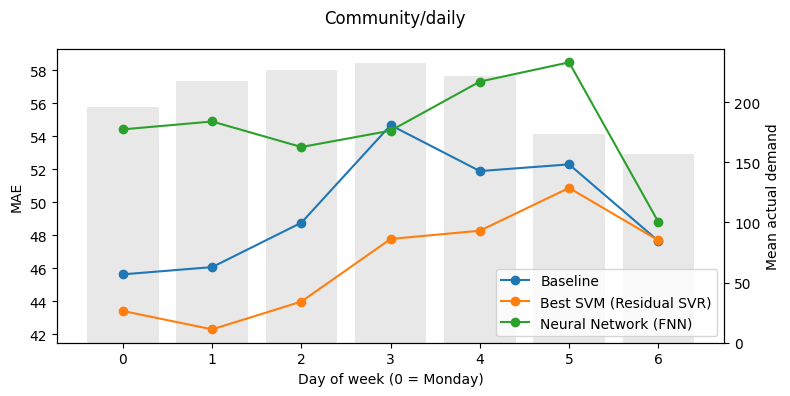

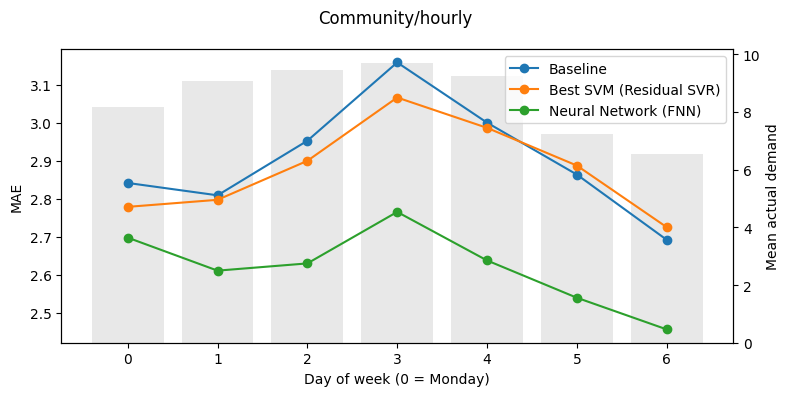

In [55]:
#| label: fig-svm-vs-nn-dayofweek
#| fig-cap: "Test MAE by day of week per temporal resolution."
#| fig-subcap:
#|   - ""
#|   - ""
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f"Community/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("MAE")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

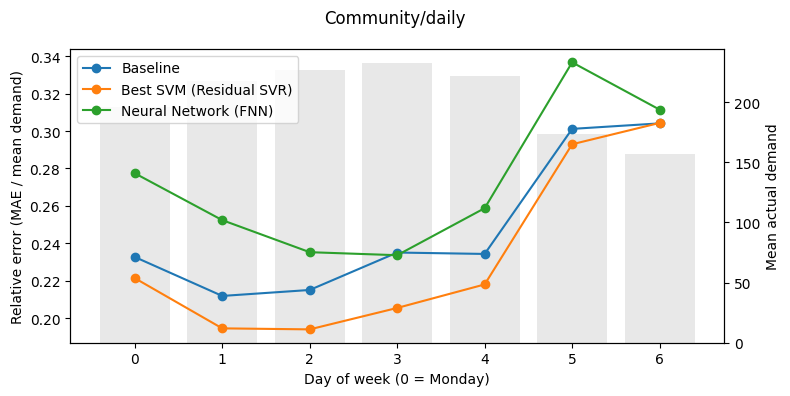

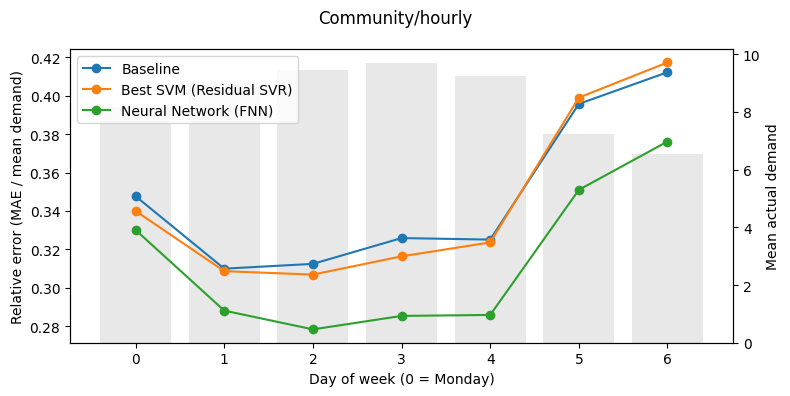

In [56]:
#| label: fig-svm-vs-nn-dayofweek-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by day of week per temporal resolution."
#| fig-subcap:
#|   - ""
#|   - ""
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
               for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f"Community/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("Relative error (MAE / mean demand)")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

### Error throughout the day

Only Community/Hourly carries an hour_of_day feature, so this breakdown is hourly-only. It shows
whether errors concentrate around commute peaks (roughly 7-9 and 16-19) or overnight, when demand
is near zero and even small absolute misses can dominate relative error.

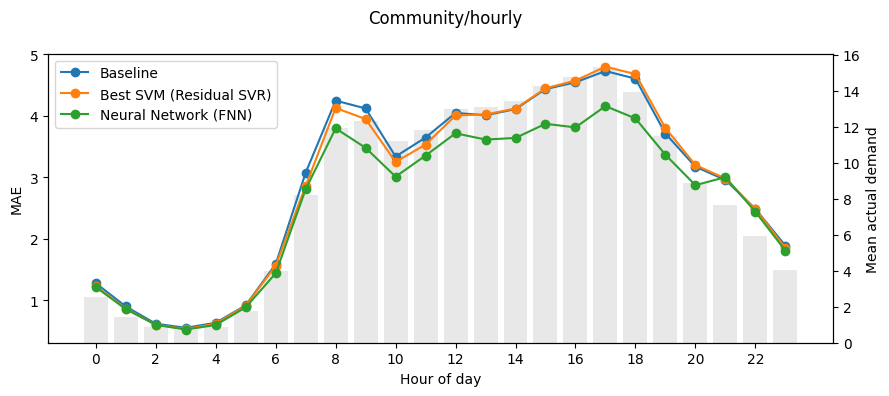

In [57]:
#| label: fig-svm-vs-nn-hourofday
#| fig-cap: "Test MAE by hour of day (Community/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Community/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("MAE")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

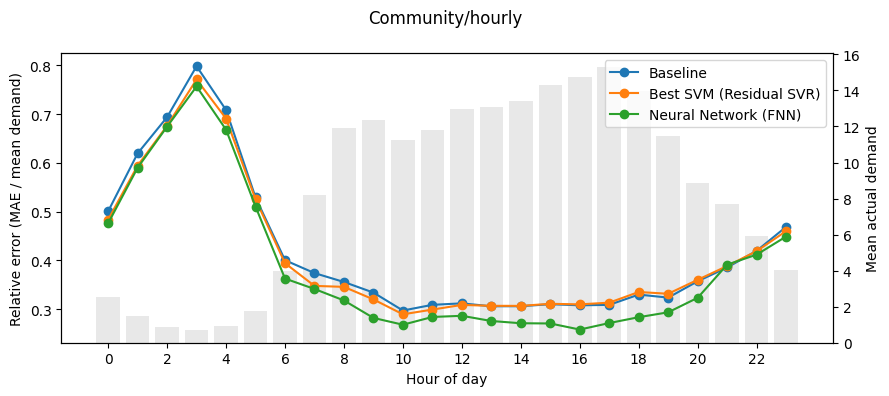

In [58]:
#| label: fig-svm-vs-nn-hourofday-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by hour of day (Community/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
           for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Community/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Relative error (MAE / mean demand)")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

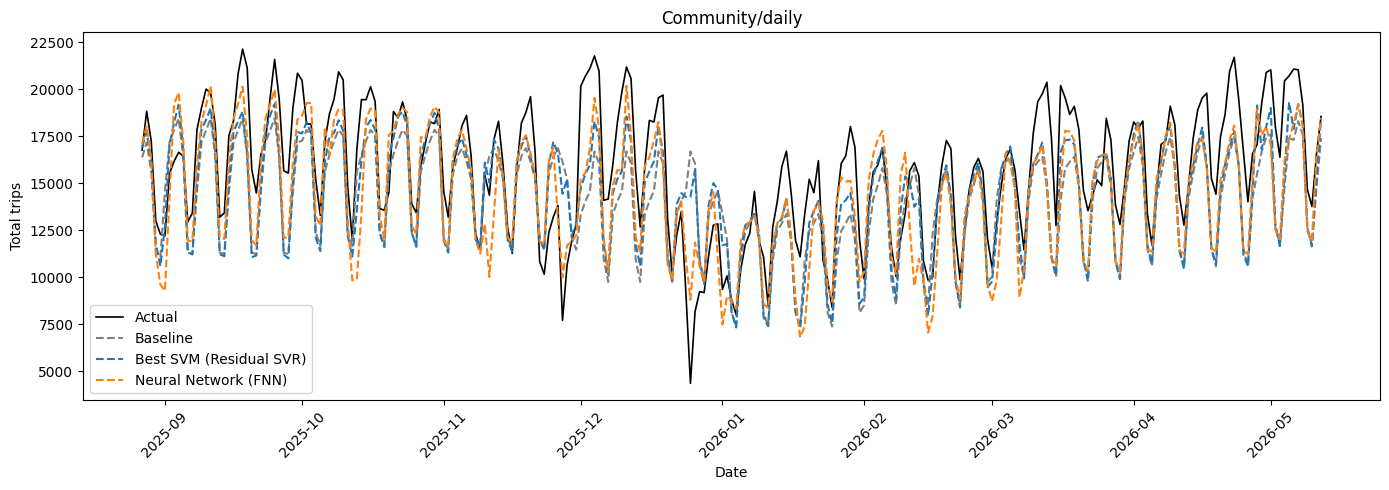

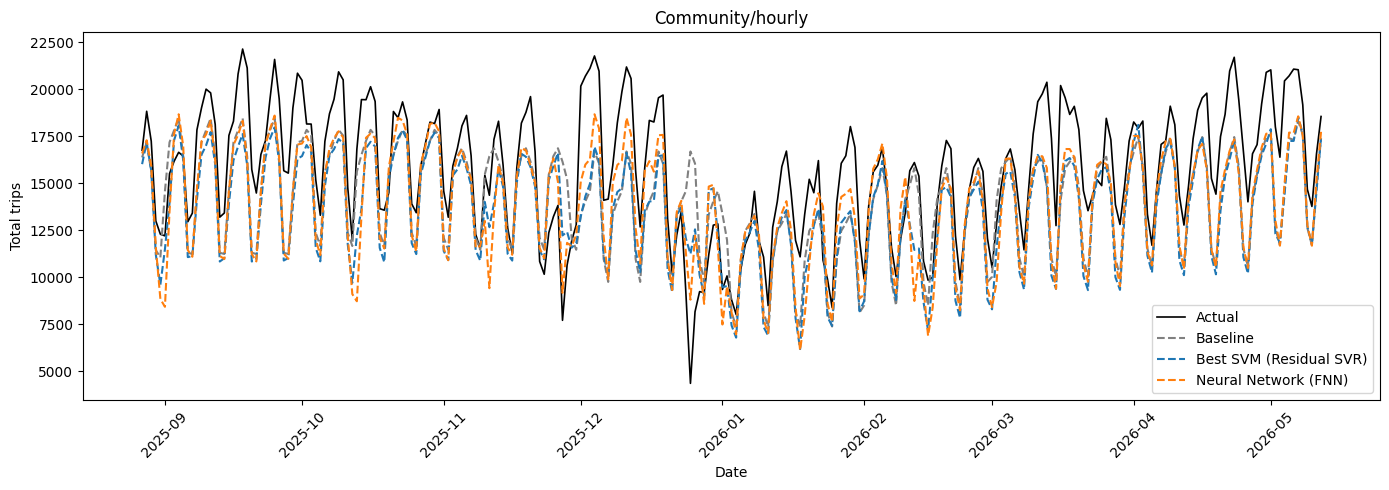

In [59]:
#| label: fig-svm-vs-nn-timeseries
#| fig-cap: "City-wide demand over the test period per temporal resolution."
#| fig-subcap:
#|   - ""
#|   - ""
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    ts = testing_df.copy()
    ts["date"] = pd.to_datetime(ts["timestamp"]).dt.date
    daily_agg = ts.groupby("date").agg(
        actual=(TRUTH, "sum"),
        baseline=(BASELINE_COL, "sum"),
    ).reset_index()
    for p in predictions.values():
        daily_agg[p["name"]] = ts.groupby("date")[p["col"]].sum().values

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_title(f"Community/{temporal}")
    ax.plot(daily_agg["date"], daily_agg["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(daily_agg["date"], daily_agg["baseline"], label="Baseline", linestyle="--", color="gray")
    for p in predictions.values():
        ax.plot(daily_agg["date"], daily_agg[p["name"]], label=p["name"], linestyle="--")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total trips")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## When does each model do best?

The maps above show *where* errors fall; this table shows *when*. It breaks test MAE down by
demand magnitude (zero / low / medium / high) and by weather (dry vs. rainy days), so a model that
wins overall but loses on, say, the busiest cells or on rainy days is not hidden behind a single
average. The same segmentation `3.6b` uses for the direct-vs-residual comparison.

In [60]:
#| label: tbl-svm-vs-nn-segments
#| tbl-cap: "Test MAE, relative error, and skill score by demand band and weather per temporal resolution."
#| tbl-subcap:
#|   - "community/daily"
#|   - "community/hourly"
def segment_masks(df, y):
    df["is_rainy"] = (df["total_precip_mm"] >= 0.1).astype(int)
    return {
        "all": np.ones(len(df), dtype=bool),
        "zero demand (y = 0)": y == 0,
        "low demand (1-10)": (y >= 1) & (y <= 10),
        "medium demand (11-100)": (y > 10) & (y <= 100),
        "high demand (> 100)": y > 100,
        "dry days": df["is_rainy"].values == 0,
        "rainy days": df["is_rainy"].values == 1,
    }

def row_rel_error(y_true, y_pred):
    """Per-row relative error |y_true - y_pred| / y_true; undefined (NaN) where y_true == 0."""
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.abs(y_true - y_pred) / y_true
    return np.where(y_true == 0, np.nan, rel)

segment_tables = {}
segment_order = {}
for temporal, testing_df in comparisons.items():
    y_true = testing_df[TRUTH].values
    rel_err_rows = {"Baseline": row_rel_error(y_true, testing_df[BASELINE_COL].values)}
    for p in predictions.values():
        rel_err_rows[p["name"]] = row_rel_error(y_true, testing_df[p["col"]].values)

    rows = []
    for seg_name, mask in segment_masks(testing_df, y_true).items():
        if mask.sum() == 0:
            continue
        mean_actual = y_true[mask].mean()
        rows.append({"segment": seg_name, "Model": "Baseline", "n": int(mask.sum()),
                     "mean_actual": mean_actual,
                     "MAE": mean_absolute_error(y_true[mask], testing_df[BASELINE_COL].values[mask]),
                     "rel_error": np.nanmean(rel_err_rows["Baseline"][mask])})
        for p in predictions.values():
            rows.append({"segment": seg_name, "Model": p["name"], "n": int(mask.sum()),
                         "mean_actual": mean_actual,
                         "MAE": mean_absolute_error(y_true[mask], testing_df[p["col"]].values[mask]),
                         "rel_error": np.nanmean(rel_err_rows[p["name"]][mask])})
    seg_df = pd.DataFrame(rows)
    baseline_mae = seg_df.loc[seg_df["Model"] == "Baseline"].set_index("segment")["MAE"]
    # Skill score vs. the historical-mean baseline: 1 = perfect, 0 = ties baseline, < 0 = worse than baseline.
    seg_df["skill_score"] = 1 - seg_df["MAE"] / seg_df["segment"].map(baseline_mae)
    segment_tables[temporal] = seg_df
    segment_order[temporal] = seg_df["segment"].unique().tolist()
    display(seg_df.drop(columns="mean_actual").set_index(["segment", "Model"]).round(3))

n      MAE  rel_error  \
segment                Model                                                
all                    Baseline                 19943   49.575      0.499   
                       Best SVM (Residual SVR)  19943   46.337      0.476   
                       Neural Network (FNN)     19943   54.518      0.582   
zero demand (y = 0)    Baseline                   250    2.873        NaN   
                       Best SVM (Residual SVR)    250    2.721        NaN   
                       Neural Network (FNN)       250    2.893        NaN   
low demand (1-10)      Baseline                  5557    3.790      0.911   
                       Best SVM (Residual SVR)   5557    3.598      0.862   
                       Neural Network (FNN)      5557    4.391      0.992   
medium demand (11-100) Baseline                 10788   10.166      0.359   
                       Best SVM (Residual SVR)  10788    9.819      0.345   
                       Neural Network (FNN)     10788   13.234      0.460   
high demand (> 100)    Baseline                  3348  256.040      0.267   
                       Best SVM (Residual SVR)   3348  238.203      0.260   
                       Neural Network (FNN)      3348  274.604      0.294   
dry days               Baseline                 17633   49.678      0.493   
                       Best SVM (Residual SVR)  17633   46.481      0.469   
                       Neural Network (FNN)     17633   54.490      0.579   
rainy days             Baseline                  2310   48.789      0.544   
                       Best SVM (Residual SVR)   2310   45.238      0.533   
                       Neural Network (FNN)      2310   54.735      0.601   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.065  
                       Neural Network (FNN)          -0.100  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.053  
                       Neural Network (FNN)          -0.007  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)        0.051  
                       Neural Network (FNN)          -0.158  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)        0.034  
                       Neural Network (FNN)          -0.302  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.070  
                       Neural Network (FNN)          -0.073  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)        0.064  
                       Neural Network (FNN)          -0.097  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)        0.073  
                       Neural Network (FNN)          -0.122

n     MAE  rel_error  \
segment                Model                                                
all                    Baseline                 478632   2.903      0.597   
                       Best SVM (Residual SVR)  478632   2.878      0.595   
                       Neural Network (FNN)     478632   2.620      0.559   
zero demand (y = 0)    Baseline                 230578   0.507        NaN   
                       Best SVM (Residual SVR)  230578   0.409        NaN   
                       Neural Network (FNN)     230578   0.428        NaN   
low demand (1-10)      Baseline                 202066   1.379      0.653   
                       Best SVM (Residual SVR)  202066   1.389      0.651   
                       Neural Network (FNN)     202066   1.349      0.613   
medium demand (11-100) Baseline                  33792  12.172      0.394   
                       Best SVM (Residual SVR)   33792  11.927      0.387   
                       Neural Network (FNN)      33792  10.801      0.353   
high demand (> 100)    Baseline                  12196  47.763      0.240   
                       Best SVM (Residual SVR)   12196  49.147      0.243   
                       Neural Network (FNN)      12196  42.466      0.219   
dry days               Baseline                 421036   2.868      0.596   
                       Best SVM (Residual SVR)  421036   2.849      0.592   
                       Neural Network (FNN)     421036   2.590      0.557   
rainy days             Baseline                  57596   3.157      0.607   
                       Best SVM (Residual SVR)   57596   3.084      0.614   
                       Neural Network (FNN)      57596   2.837      0.569   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.009  
                       Neural Network (FNN)           0.097  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.194  
                       Neural Network (FNN)           0.156  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.007  
                       Neural Network (FNN)           0.022  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)        0.020  
                       Neural Network (FNN)           0.113  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.029  
                       Neural Network (FNN)           0.111  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)        0.007  
                       Neural Network (FNN)           0.097  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)        0.023  
                       Neural Network (FNN)           0.101

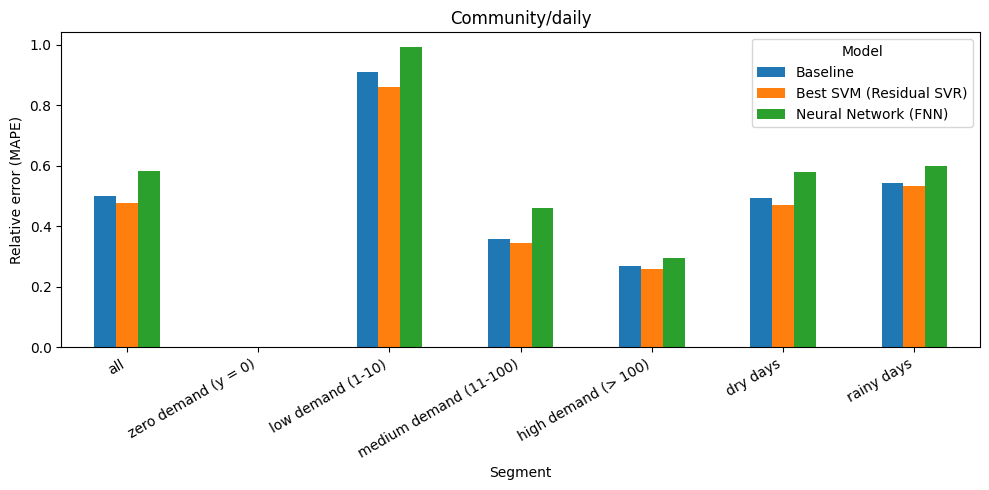

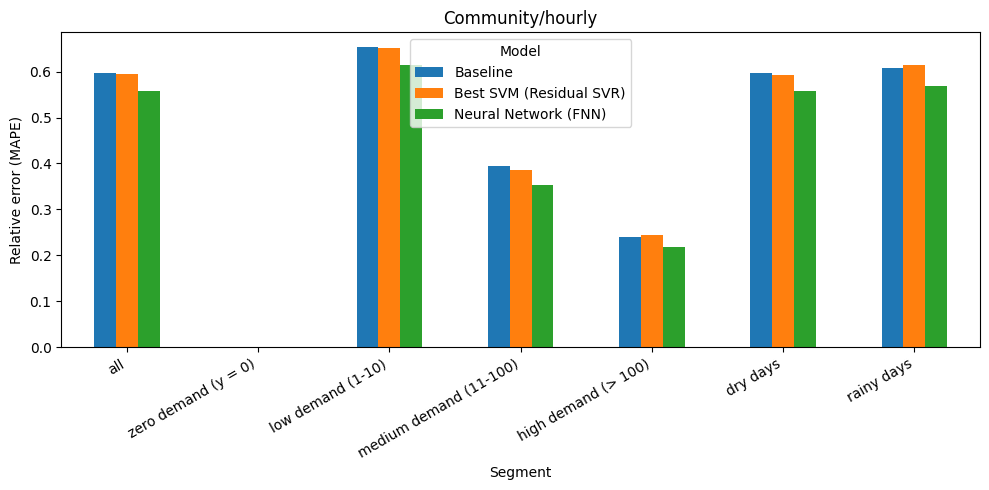

In [61]:
#| label: fig-svm-vs-nn-segments-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by segment per temporal resolution."
#| fig-subcap:
#|   - ""
#|   - ""
#| layout-ncol: 1
model_order = ["Baseline"] + [p["name"] for p in predictions.values()]
for temporal, seg_df in segment_tables.items():
    pivot = seg_df.pivot(index="segment", columns="Model", values="rel_error")
    pivot = pivot.loc[segment_order[temporal], model_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Community/{temporal}")
    ax.set_xlabel("Segment")
    ax.set_ylabel("Relative error (MAPE)")
    ax.legend(title="Model")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()